In [ ]:
!pip install -U numexpr copulas

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from scipy.stats import expon
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from copulas.multivariate import GaussianMultivariate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
import numpy as np

In [5]:
# nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

In [6]:
# unisco il dataset con le classificazioni
dataset = pd.read_csv('dataset.csv')

classifications = pd.read_csv('descrizioni_classificate.csv')

event_mapped = dict(zip(classifications['Descrizione'], classifications['Tipo_Evento']))

dataset['Tipo_Evento'] = dataset['Descrizione'].map(event_mapped)

dataset.to_csv('dataset_classificato.csv', index=False)

In [8]:
#filtro il dataset per il componente VEHICLE e rimuovo le colonne vuote
print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")

df_vehicle = dataset[dataset['Componente'] == 'VEHICLE']

df_vehicle_cleaned = df_vehicle.dropna(axis=1, how='all')

print(f"Numero di righe dopo il filtraggio: {df_vehicle_cleaned.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {df_vehicle_cleaned.shape[1]}")

Numero di righe prima del filtraggio: 57652
Numero di colonne prima della rimozione di colonne vuote: 170
Numero di righe dopo il filtraggio: 15277
Numero di colonne dopo la rimozione di colonne vuote: 58


In [12]:
#rumuovo le righe che contengono valori mancanti
df_cleaned_no_nan = df_vehicle_cleaned.dropna()

df_cleaned_no_nan.isnull().sum().sum(), df_cleaned_no_nan.shape

df_cleaned_no_nan.to_csv('dataset_cleaned.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [16]:
#leggo il file csv e pulisco i dati
df_cleaned_no_nan['Timestamp'] = pd.to_datetime(df_cleaned_no_nan['Timestamp'], errors='coerce')

vehicle_data_clean = df_cleaned_no_nan.dropna(subset=['Timestamp', 'Timestamp chiusura'])

vehicle_data_clean = vehicle_data_clean.drop_duplicates(subset=['Descrizione', 'Timestamp'])

print(f"Righe rimaste dopo la pulizia: {len(vehicle_data_clean)}")

Righe rimaste dopo la pulizia: 4010


/tmp/ipykernel_77476/471781422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_no_nan['Timestamp'] = pd.to_datetime(df_cleaned_no_nan['Timestamp'], errors='coerce')


In [17]:
#calcolo il tempo di interarrivo medio tra le anomalie
anomalies = vehicle_data_clean[vehicle_data_clean['Tipo_Evento'] == 'Anomalia']

anomalies_sorted = anomalies.sort_values(by='Timestamp')

anomalies_sorted['Interarrival_Time'] = anomalies_sorted['Timestamp'].diff().dt.total_seconds()

anomalies_interarrival = anomalies_sorted['Interarrival_Time'].dropna()

print(f"Numero di anomalie dopo il calcolo del tempo di interarrivo: {len(anomalies_interarrival)}")

Numero di anomalie dopo il calcolo del tempo di interarrivo: 1811


In [18]:
#filtro le anomalie per la deviazione standard
mean_anomalies = anomalies_interarrival.mean()

std_anomalies = anomalies_interarrival.std()

filtered_anomalies_interarrival = anomalies_interarrival[
    (anomalies_interarrival > mean_anomalies - 2 * std_anomalies) &
    (anomalies_interarrival < mean_anomalies + 2 * std_anomalies)
]

print(f"Numero di anomalie dopo il filtraggio: {len(filtered_anomalies_interarrival)}")

Numero di anomalie dopo il filtraggio: 1790


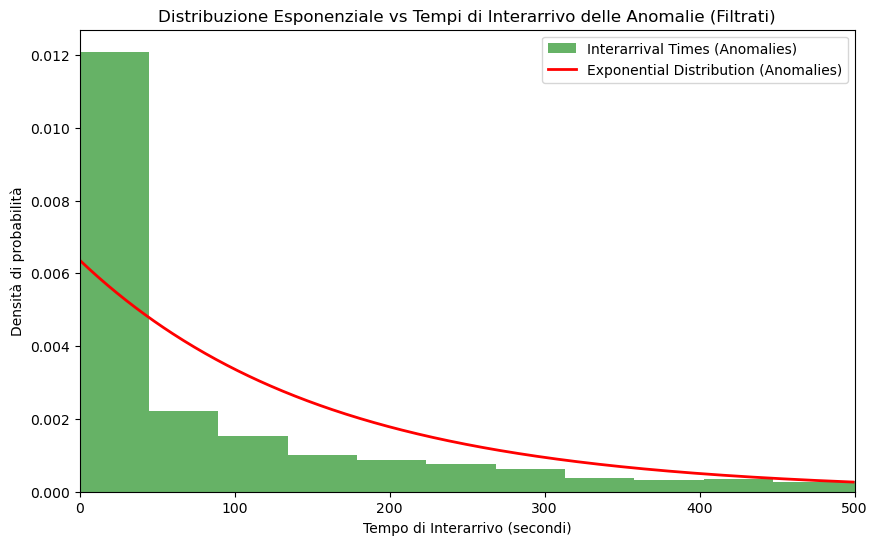

In [19]:
#distribuzione esponenziale sui tempi di interarrivo delle anomalie, filtrato per deviazione standard maggiore di 2
lambda_expon_anomalies = 1 / filtered_anomalies_interarrival.mean()
x_limit = 500
expon_distribution_anomalies = expon.pdf(range(x_limit), scale=1/lambda_expon_anomalies)



In [20]:
#calcolo il tempo di interarrivo medio tra i funzionamenti normali
normal_operations = vehicle_data_clean[vehicle_data_clean['Tipo_Evento'] == 'Funzionamento Normale']

normal_operations_sorted = normal_operations.sort_values(by='Timestamp')

normal_operations_sorted['Interarrival_Time'] = normal_operations_sorted['Timestamp'].diff().dt.total_seconds()

normal_interarrival = normal_operations_sorted['Interarrival_Time'].dropna()

print(f"Numero di operazioni normali dopo il calcolo del tempo di interarrivo: {len(normal_interarrival)}")

Numero di operazioni normali dopo il calcolo del tempo di interarrivo: 2197


In [21]:
#filtro i log di funzionamento nornmale per la deviazione standard
mean_normal = normal_interarrival.mean()

std_normal = normal_interarrival.std()

filtered_normal_interarrival = normal_interarrival[
    (normal_interarrival > mean_normal - 2 * std_normal) &
    (normal_interarrival < mean_normal + 2 * std_normal)
]

print(f"Numero di operazioni normali dopo il filtraggio: {len(filtered_normal_interarrival)}")

Numero di operazioni normali dopo il filtraggio: 2172


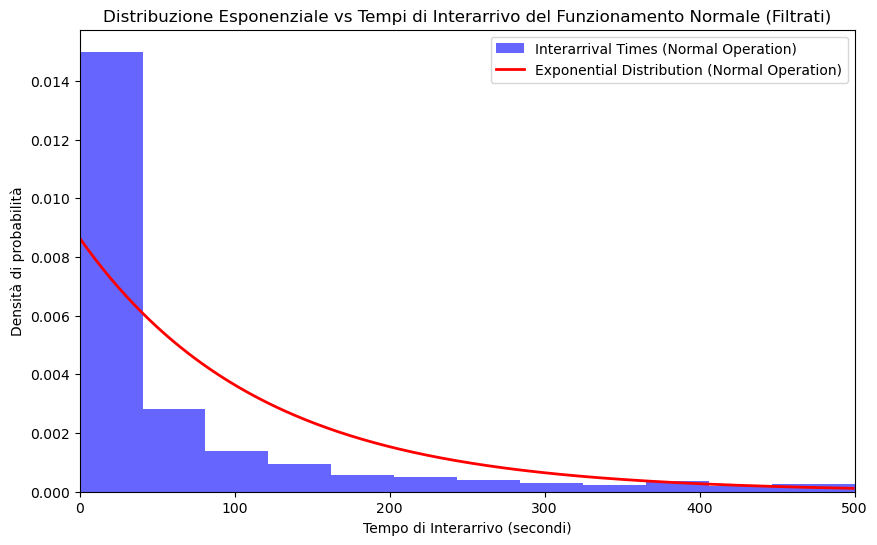

In [22]:
#distribuzione esponenziale sui tempi di interarrivo del funzionamento normale, filtrato per deviazione standard maggiore di 2
lambda_expon_normal = 1 / filtered_normal_interarrival.mean()
expon_distribution_normal = expon.pdf(range(x_limit), scale=1/lambda_expon_normal)



In [23]:
#calcolo media e mediana dei tempi di interarrivo delle anomalie e del funzionamento normale
mean_filtered_anomalies = filtered_anomalies_interarrival.mean()
median_filtered_anomalies = filtered_anomalies_interarrival.median()
print(f"Media dei tempi di interarrivo delle anomalie filtrate: {mean_filtered_anomalies}")
print(f"Mediana dei tempi di interarrivo delle anomalie filtrate: {median_filtered_anomalies}")

mean_filtered_normal = filtered_normal_interarrival.mean()
median_filtered_normal = filtered_normal_interarrival.median()
print(f"Media dei tempi di interarrivo del funzionamento normale filtrato: {mean_filtered_normal}")
print(f"Mediana dei tempi di interarrivo del funzionamento normale filtrato: {median_filtered_normal}")

Media dei tempi di interarrivo delle anomalie filtrate: 157.1141134078212
Mediana dei tempi di interarrivo delle anomalie filtrate: 30.200499999999998
Media dei tempi di interarrivo del funzionamento normale filtrato: 115.65564917127072
Mediana dei tempi di interarrivo del funzionamento normale filtrato: 22.298499999999997


In [24]:
#caricare il dataset e selezionare i dati
print(f"Dataset caricato con {len(df_cleaned_no_nan)} righe.")

df_anomalie = df_cleaned_no_nan[df_cleaned_no_nan['Tipo_Evento_Classificato'] == 0]
df_normali = df_cleaned_no_nan[df_cleaned_no_nan['Tipo_Evento_Classificato'] == 1]
print(f"Eventi di anomalia selezionati: {len(df_anomalie)} righe.")
print(f"Eventi di funzionamento normale selezionati: {len(df_normali)} righe.")

Dataset caricato con 14356 righe.
Eventi di anomalia selezionati: 7766 righe.
Eventi di funzionamento normale selezionati: 6590 righe.


In [26]:
#creatzione modello e valutazione accuratezza
X_final = df_cleaned_no_nan.drop(columns=['Tipo_Evento_Classificato', 'Tipo_Evento', 'Descrizione', 'Timestamp', 'Timestamp chiusura', 'Posizione', 'Flotta', 'Veicolo', 'Codice', 'Nome', 'Test', 'Longitudine', 'Latitudine', 'Contemporaneo'])

y_final = df_cleaned_no_nan['Tipo_Evento_Classificato']

y_final = y_final.replace({1: 'Funzionamento Normale', 0: 'Anomalia'})

non_numeric_columns = X_final.select_dtypes(include=['object']).columns

X_final = X_final.drop(columns=non_numeric_columns)

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Anomalia', 'Funzionamento Normale'])

print(f"Accuratezza del modello: {accuracy:.4f}")
print("Report di classificazione:")
print(classification_rep)

Accuratezza del modello: 0.8653
Report di classificazione:
                       precision    recall  f1-score   support

             Anomalia       0.87      0.88      0.88      1569
Funzionamento Normale       0.86      0.84      0.85      1303

             accuracy                           0.87      2872
            macro avg       0.86      0.86      0.86      2872
         weighted avg       0.87      0.87      0.87      2872



In [27]:
#rimuovo i duplicati consecutivi
columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']

df_deduplicated_anomalies = df_anomalie.loc[(df_anomalie[columns_to_check] != df_anomalie[columns_to_check].shift()).any(axis=1)]

print(f"Righe originali: {len(df_anomalie)}")
print(f"Righe dopo rimozione delle ridondanze: {len(df_deduplicated_anomalies)}")


Righe originali: 7766
Righe dopo rimozione delle ridondanze: 1828


In [28]:
#rimuovo i duplicati consecutivi
columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']

df_deduplicated_normals = df_normali.loc[(df_normali[columns_to_check] != df_normali[columns_to_check].shift()).any(axis=1)]

print(f"Righe originali: {len(df_normali)}")
print(f"Righe dopo rimozione delle ridondanze: {len(df_deduplicated_normals)}")


Righe originali: 6590
Righe dopo rimozione delle ridondanze: 2198


In [29]:
#generazione dati sintetici con copula gaussiana
warnings.filterwarnings("ignore", category=RuntimeWarning)

data_us_anomalie = df_deduplicated_anomalies[columns_to_generate].drop(columns=['Durata'])
data_us_normali = df_deduplicated_normals[columns_to_generate].drop(columns=['Durata'])

copula_us_anomalie = GaussianMultivariate()
copula_us_anomalie.fit(data_us_anomalie)

copula_us_normali = GaussianMultivariate()
copula_us_normali.fit(data_us_normali)

synthetic_us_anomalie = copula_us_anomalie.sample(len(data_us_anomalie))
synthetic_us_normali = copula_us_normali.sample(len(data_us_normali))

alpha = 0.2
beta = 1.9

media_durata_anomalie = 157 * alpha
media_durata_normali = 115 * alpha

sigma_anomalie = 1 * beta
sigma_normali = 1 * beta

synthetic_us_anomalie['Durata'] = np.random.lognormal(mean=np.log(media_durata_anomalie), sigma=sigma_anomalie, size=len(synthetic_us_anomalie))
synthetic_us_normali['Durata'] = np.random.lognormal(mean=np.log(media_durata_normali), sigma=sigma_normali, size=len(synthetic_us_normali))

synthetic_us_anomalie['Tipo_Evento'] = "Anomalia"
synthetic_us_normali['Tipo_Evento'] = "Funzionamento Normale"

synthetic_us_anomalie['Tipo_Evento_Classificato'] = 0
synthetic_us_normali['Tipo_Evento_Classificato'] = 1

warnings.filterwarnings("default", category=RuntimeWarning)

In [30]:
#sposto colonna durata in prima posizione e salvo i dataset
col_durata_anomalie = synthetic_us_anomalie.pop('Durata')
synthetic_us_anomalie.insert(0, 'Durata', col_durata_anomalie)

col_durata_normali = synthetic_us_normali.pop('Durata')
synthetic_us_normali.insert(0, 'Durata', col_durata_normali)

synthetic_us_anomalie.to_csv('dataset_sintetico_anomalie.csv', index=False)
synthetic_us_normali.to_csv('dataset_sintetico_normali.csv', index=False)

In [31]:
#calcolo media e mediana dei tempi di interarrivo delle anomalie e del funzionamento normale
mean_filtered_synthetic_anomalies = synthetic_us_anomalie['Durata'].mean()
median_filtered_synthetic_anomalies = synthetic_us_anomalie['Durata'].median()
print(f"Media dei tempi di interarrivo delle anomalie filtrate: {mean_filtered_synthetic_anomalies}")
print(f"Mediana dei tempi di interarrivo delle anomalie filtrate: {median_filtered_synthetic_anomalies}")

mean_filtered_synthetic_normal = synthetic_us_normali['Durata'].mean()
median_filtered_synthetic_normal = synthetic_us_normali['Durata'].median()
print(f"Media dei tempi di interarrivo del funzionamento normale filtrato: {mean_filtered_synthetic_normal}")
print(f"Mediana dei tempi di interarrivo del funzionamento normale filtrato: {median_filtered_synthetic_normal}")

Media dei tempi di interarrivo delle anomalie filtrate: 156.1167759905403
Mediana dei tempi di interarrivo delle anomalie filtrate: 31.415311398070877
Media dei tempi di interarrivo del funzionamento normale filtrato: 134.407088509556
Mediana dei tempi di interarrivo del funzionamento normale filtrato: 22.910597574639077


# sep

In [38]:
def aggiungoRigaAlFileDiDestinazione(file_output, file_anomalie, file_normali):
    global timestamp_iniziale

    if np.random.rand() < 0.5:
        dataset_file = file_anomalie
        tipo_evento = 'Anomalia'
        tipo_evento_classificato = 0
    else:
        dataset_file = file_normali
        tipo_evento = 'Funzionamento Normale'
        tipo_evento_classificato = 1

    dataset_sintetico = pd.read_csv(dataset_file)
    nuova_riga = dataset_sintetico.iloc[0].copy()
    dataset_sintetico = dataset_sintetico.iloc[1:]

    nuova_riga['Timestamp'] = timestamp_iniziale
    nuova_riga['Timestamp chiusura'] = timestamp_iniziale + pd.to_timedelta(nuova_riga['Durata'], unit='s')
    nuova_riga['Timestamp segnale'] = timestamp_iniziale + timedelta(seconds=uniform(0, 1))

    nuova_riga['Tipo_Evento'] = tipo_evento
    nuova_riga['Tipo_Evento_Classificato'] = tipo_evento_classificato

    if not os.path.exists(file_output):
        nuova_riga.to_frame().T.to_csv(file_output, mode='a', header=all_columns, index=False)
    else:
        nuova_riga.to_frame().T.to_csv(file_output, mode='a', header=False, index=False)

    dataset_sintetico.to_csv(dataset_file, index=False)

    timestamp_iniziale = pd.Timestamp.now()
    print(f"Riga sintetica aggiunta dal dataset {tipo_evento}")

def generazioneContinuataDataset(file_output, file_anomalie, file_normali, df_anomalie, df_normali, soglia=100, num_righe_rigenerazione=1000):
    executor = ThreadPoolExecutor(max_workers=2)
    rigenerazione_in_corso = None
    
    while True:
        dataset_anomalie = pd.read_csv(file_anomalie)
        dataset_normali = pd.read_csv(file_normali)

        if (len(dataset_anomalie) < soglia or len(dataset_normali) < soglia) and rigenerazione_in_corso is None:
            rigenerazione_in_corso = executor.submit(
                rigeneraDatasetSintetico, file_anomalie, file_normali, df_anomalie, df_normali, num_righe_rigenerazione
            )
            print("Rigenerazione del dataset sintetico avviata in parallelo.")

        durata = dataset_anomalie.iloc[0].get('Durata', 1) if np.random.rand() < 0.5 else dataset_normali.iloc[0].get('Durata', 1)
        time.sleep(durata)
        aggiungoRigaAlFileDiDestinazione(file_output, file_anomalie, file_normali)

        if rigenerazione_in_corso and rigenerazione_in_corso.done():
            print("Rigenerazione completata.")
            rigenerazione_in_corso = None

In [39]:
# script per la generazione continua di dati sintetici
import pandas as pd
import numpy as np
import time
from concurrent.futures import ThreadPoolExecutor
from copulas.multivariate import GaussianMultivariate
import warnings
import os
from datetime import timedelta
from random import uniform

columns_to_generate = [
    'Durata', 'CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7',
    'HMI_DCPntSts_T2', 'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2',
    'HMI_VBatt_T4', 'HMI_VBatt_T5', 'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel',
    'MDS_StatoMarcia', '_GPS_LAT', '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3',
    'usB1BCilPres_M6', 'usB1BCilPres_M8', 'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7',
    'usB2BCilPres_M1', 'usB2BCilPres_M3', 'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4',
    'usB2BCilPres_T5', 'usB2BCilPres_T7', 'usBpPres', 'usMpPres'
]

all_columns = [
    'Flotta', 'Veicolo', 'Codice', 'Nome', 'Descrizione', 'Test', 'Timestamp', 'Timestamp chiusura', 'Durata', 
    'Posizione', 'Sistema', 'Componente', 'Latitudine', 'Longitudine', 'Contemporaneo', 'Timestamp segnale'
] + columns_to_generate + ['Tipo_Evento', 'Tipo_Evento_Classificato']

timestamp_iniziale = pd.Timestamp.now()

df_originale = pd.read_csv('dataset_cleaned.csv')
df_anomalie = df_originale[df_originale['Tipo_Evento'] == 'Anomalia']
df_normali = df_originale[df_originale['Tipo_Evento'] == 'Funzionamento Normale']

columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']
df_deduplicated_anomalies = df_anomalie.loc[(df_anomalie[columns_to_check] != df_anomalie[columns_to_check].shift()).any(axis=1)]
df_deduplicated_normals = df_normali.loc[(df_normali[columns_to_check] != df_normali[columns_to_check].shift()).any(axis=1)]

In [42]:
file_anomalie = 'dataset_sintetico_anomalie.csv'
file_normali = 'dataset_sintetico_normali.csv'
df_anomalie = df_deduplicated_anomalies[columns_to_generate]
df_normali = df_deduplicated_normals[columns_to_generate]
num_righe = 1000

warnings.filterwarnings("ignore", category=RuntimeWarning)

df_anomalie_copula = df_anomalie.drop(columns=['Durata'], errors='ignore')
df_normali_copula = df_normali.drop(columns=['Durata'], errors='ignore')

copula_anomalie = GaussianMultivariate()
copula_anomalie.fit(df_anomalie_copula)
synthetic_anomalie = copula_anomalie.sample(num_righe // 2)

copula_normali = GaussianMultivariate()
copula_normali.fit(df_normali_copula)
synthetic_normali = copula_normali.sample(num_righe // 2)

alpha = 0.2
beta = 1.9
media_durata_anomalie = 157 * alpha
media_durata_normali = 115 * alpha
sigma_anomalie = 1 * beta
sigma_normali = 1 * beta

synthetic_anomalie['Durata'] = np.random.lognormal(mean=np.log(media_durata_anomalie), sigma=sigma_anomalie, size=len(synthetic_anomalie))
synthetic_normali['Durata'] = np.random.lognormal(mean=np.log(media_durata_normali), sigma=sigma_normali, size=len(synthetic_normali))

In [ ]:

for df in [synthetic_anomalie, synthetic_normali]:
    df['Flotta'] = 'ETR700'
    df['Veicolo'] = 'e700_4801'
    df['Test'] = 'N'
    df['Timestamp'] = pd.Timestamp.now()
    df['Timestamp chiusura'] = df['Timestamp'] + pd.to_timedelta(df['Durata'], unit='s')
    df['Posizione'] = np.nan
    df['Sistema'] = 'VEHICLE'
    df['Componente'] = 'VEHICLE'
    df['Timestamp segnale'] = np.nan

for col in all_columns:
    if col not in synthetic_anomalie.columns:
        synthetic_anomalie[col] = np.nan
    if col not in synthetic_normali.columns:
        synthetic_normali[col] = np.nan

synthetic_anomalie = synthetic_anomalie.round(2)
synthetic_normali = synthetic_normali.round(2)

synthetic_anomalie = synthetic_anomalie[all_columns]
synthetic_normali = synthetic_normali[all_columns]

synthetic_anomalie.to_csv(file_anomalie, index=False)
synthetic_normali.to_csv(file_normali, index=False)

warnings.filterwarnings("default", category=RuntimeWarning)
print(f"Dataset sintetici rigenerati: {file_anomalie} e {file_normali}")


In [ ]:
generazioneContinuataDataset('dataset_destinazione.csv', 'dataset_sintetico_anomalie.csv', 'dataset_sintetico_normali.csv', df_deduplicated_anomalies[columns_to_generate], df_deduplicated_normals[columns_to_generate])


In [1]:
#test del modello sui dati sintetici
train_columns = X_final.columns

df_sintetico = pd.read_csv('dataset_destinazione.csv')

X_sintetico = df_sintetico[train_columns]
y_sintetico = df_sintetico['Tipo_Evento_Classificato'].replace({1: 'Funzionamento Normale', 0: 'Anomalia'})

y_pred_sintetico = rf_model.predict(X_sintetico)

accuracy_sintetico = accuracy_score(y_sintetico, y_pred_sintetico)
classification_rep_sintetico = classification_report(y_sintetico, y_pred_sintetico, target_names=['Anomalia', 'Funzionamento Normale'])

print(f"Accuratezza del modello sui dati sintetici: {accuracy_sintetico:.4f}")
print("Report di classificazione sui dati sintetici:")
print(classification_rep_sintetico)


NameError: name 'X_final' is not defined